LEAST SQUARE FIT

Least squares polynomial coefficients (Degree 1):
c0 = -0.149824
c1 = 0.957647

Least squares polynomial coefficients (Degree 2):
c0 = 0.021176
c1 = -0.542353
c2 = 1.500000

Least squares polynomial coefficients (Degree 3):
c0 = 0.000000
c1 = -0.000000
c2 = -0.000000
c3 = 1.000000



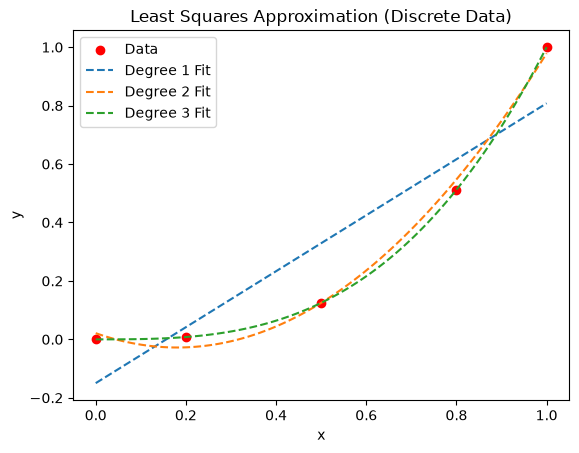

In [1]:
### Discrete Least Squares Approximation
import numpy as np
import matplotlib.pyplot as plt

# Given data
#x = np.array([1, 2, 3, 4, 5])
#y = np.array([2.2, 2.8, 3.6, 4.5, 5.1])

x = np.array([0, .2, .5, .8, 1])
y = np.array([0, .008, .125, .512, 1])

# Degrees of polynomial approximation
degrees = [1, 2, 3]  # Linear, Quadratic, and Cubic

# Plot original data
plt.scatter(x, y, label="Data", color="red")
x_fit = np.linspace(min(x), max(x), 100)

# Perform Least squares approximation for each degree
for n in degrees:
    A = np.vstack([x**i for i in range(n+1)]).T  # Design matrix
    c, _, _, _ = np.linalg.lstsq(A, y, rcond=None)  # Solve least squares

    # Construct the polynomial approximation function
    P_n = lambda x: sum(c[i] * x**i for i in range(n+1))

    # Plot the approximation
    y_fit = P_n(x_fit)
    plt.plot(x_fit, y_fit, linestyle="dashed", label=f"Degree {n} Fit")

    # Print coefficients
    print(f"Least squares polynomial coefficients (Degree {n}):")
    for i, coeff in enumerate(c):
        print(f"c{i} = {coeff:.6f}")
    print()

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Least Squares Approximation (Discrete Data)")
plt.show()


LIST SSQUARE FIT CONTINUOUS


Least squares polynomial coefficients (Degree 1):
c0 = -0.200000
c1 = 0.900000

Least squares polynomial coefficients (Degree 2):
c0 = 0.050000
c1 = -0.600000
c2 = 1.500000

Least squares polynomial coefficients (Degree 3):
c0 = 0.000000
c1 = -0.000000
c2 = 0.000000
c3 = 1.000000



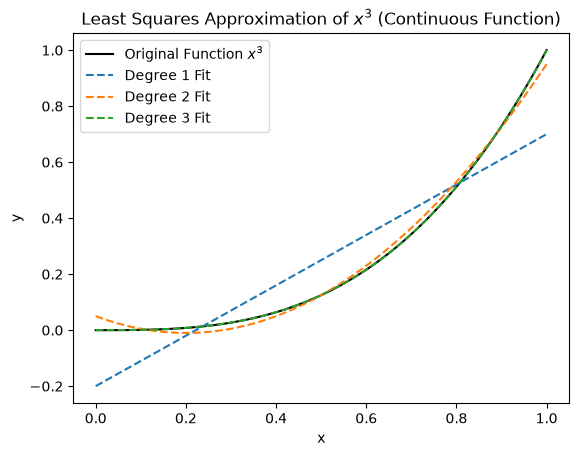

In [4]:
### Continuous Least Squares Approximation
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define the continuous function to approximate
# f = lambda x: np.exp(x)
f = lambda x: x**3

# Define the interval
a, b = 0, 1

# Degrees of polynomial approximation
degrees = [1, 2, 3]  # Linear, Quadratic, and Cubic

# Basis function generator
def basis_funcs(n):
    return [lambda x, i=i: x**i for i in range(n+1)]

# Plot original function
x_vals = np.linspace(a, b, 100)
y_vals = f(x_vals)

# plt.plot(x_vals, y_vals, label="Original Function $e^x$", color="black")
plt.plot(x_vals, y_vals, label="Original Function $x^3$", color="black")

# Perform least squares approximation for each degree
for n in degrees:
    basis = basis_funcs(n)

    A = np.zeros((n+1, n+1))
    b_vec = np.zeros(n+1)

    for i in range(n+1):
        for j in range(n+1):
            A[i, j] = quad(
                lambda x: basis[i](x) * basis[j](x),
                a, b
            )[0]

        b_vec[i] = quad(
            lambda x: f(x) * basis[i](x),
            a, b
        )[0]

    # Solve for coefficients
    c = np.linalg.solve(A, b_vec)

    # Construct the approximation function
    p_n = lambda x: sum(
        c[i] * basis[i](x) for i in range(n+1)
    )

    # Plot the approximation
    y_approx = p_n(x_vals)

    plt.plot(
        x_vals,
        y_approx,
        linestyle="dashed",
        label=f"Degree {n} Fit"
    )

    # Print coefficients
    print(f"Least squares polynomial coefficients (Degree {n}):")

    for i, coeff in enumerate(c):
        print(f"c{i} = {coeff:.6f}")

    print()

plt.legend()
plt.xlabel("x")
plt.ylabel("y")

# plt.title("Least Squares Approximation of $e^x$ (Continuous Function)")
plt.title("Least Squares Approximation of $x^3$ (Continuous Function)")

plt.show()


RUNGE PHENOMENON

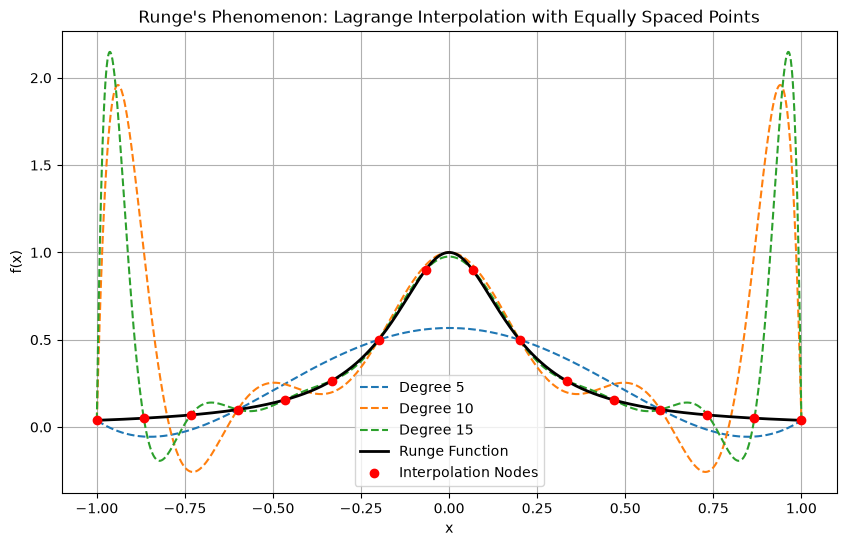

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

# Runge's function
def runge_function(x):
    return 1 / (1 + 25 * x**2)

# Generate x values for plotting the true function
x_true = np.linspace(-1, 1, 1000)
y_true = runge_function(x_true)

# Function to compute Lagrange Interpolation
def lagrange_interpolation(x_nodes, y_nodes, x_eval):
    interpolator = BarycentricInterpolator(x_nodes, y_nodes)
    return interpolator(x_eval)

# Degree of interpolation polynomials to test
degrees = [5, 10, 15]

plt.figure(figsize=(10, 6))

for n in degrees:
    # Equally spaced interpolation nodes
    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = runge_function(x_nodes)

    # Compute interpolation
    y_interp = lagrange_interpolation(x_nodes, y_nodes, x_true)

    # Plot results
    plt.plot(x_true, y_interp, label=f"Degree {n}", linestyle='--')

# Plot the true function
plt.plot(x_true, y_true, 'k-', label="Runge Function", linewidth=2)

# Plot interpolation nodes for highest degree
plt.scatter(x_nodes, y_nodes, color='red', zorder=3, label="Interpolation Nodes")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Runge's Phenomenon: Lagrange Interpolation with Equally Spaced Points")
plt.legend()
plt.grid(True)
plt.show()
